In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(exist_ok=True)

# Load cleaned NAV data
nav = pd.read_csv(DATA_DIR / "02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

print("NAV Shape:", nav.shape)
nav.head()

NAV Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(exist_ok=True)

# Load cleaned NAV data
nav = pd.read_csv(DATA_DIR / "02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

print("NAV Shape:", nav.shape)
nav.head()

NAV Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(exist_ok=True)

# Load cleaned NAV data
nav = pd.read_csv(DATA_DIR / "02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

print("NAV Shape:", nav.shape)
nav.head()

NAV Shape: (46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change(fill_method=None)
)

nav["daily_return"] = nav["daily_return"].replace(
    [np.inf, -np.inf], np.nan
)

returns = nav.dropna(subset=["daily_return"]).copy()

print("Return observations:", returns.shape)
returns.head()

Return observations: (45960, 4)


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [9]:
def calculate_var_cvar(group):
    r = group["daily_return"].dropna()

    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()

    return pd.Series({
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "Observations": len(r)
    })

var_report = (
    returns.groupby("amfi_code")
           .apply(calculate_var_cvar)
           .reset_index()
)

# Convert returns to percentage
var_report["VaR_95_pct"] = var_report["VaR_95"] * 100
var_report["CVaR_95_pct"] = var_report["CVaR_95"] * 100

# Add fund names
fund_info = fund_master_[
    ["amfi_code", "scheme_name", "fund_house", "category"]
].drop_duplicates("amfi_code")

var_report = var_report.merge(
    fund_info,
    on="amfi_code",
    how="left"
)

var_report = var_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "VaR_95_pct",
        "CVaR_95_pct",
        "Observations"
    ]
]

var_report.to_csv(
    REPORTS_DIR / "var_cvar_report.csv",
    index=False
)

print("Funds analysed:", len(var_report))
var_report.head(10)

C:\Users\saisr\AppData\Local\Temp\ipykernel_22412\1657699287.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_var_cvar)


NameError: name 'fund_master_' is not defined

In [10]:
fund_master = pd.read_csv(
    get_file(
        "01_fund_master.csv",
        "01_fund_master_cleaned.csv"
    )
)

fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)

print(fund_master.shape)
fund_master.head()

NameError: name 'get_file' is not defined

In [11]:
from pathlib import Path
import pandas as pd

# Find project root
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Mutual_Fund_Analytics project folder not found")

DATA_DIR = PROJECT_ROOT / "data" / "processed"

# Try possible fund master filenames
file1 = DATA_DIR / "01_fund_master.csv"
file2 = DATA_DIR / "01_fund_master_cleaned.csv"

if file1.exists():
    fund_master = pd.read_csv(file1)
elif file2.exists():
    fund_master = pd.read_csv(file2)
else:
    raise FileNotFoundError("Fund master CSV not found in data/processed")

fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)

print("Loaded:", fund_master.shape)
print(fund_master.columns.tolist())

fund_master.head()

Loaded: (40, 15)
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# Paths
# -----------------------------
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

# -----------------------------
# Load NAV data
# -----------------------------
nav_file = DATA_DIR / "02_nav_history_cleaned.csv"

if not nav_file.exists():
    nav_file = DATA_DIR / "02_nav_history.csv"

nav = pd.read_csv(nav_file)

nav["amfi_code"] = nav["amfi_code"].astype(str)
nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

nav = nav.sort_values(["amfi_code", "date"])

# Daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change(fill_method=None)
)

returns = nav.dropna(subset=["daily_return"]).copy()

# -----------------------------
# VaR 95%
# -----------------------------
var_95 = (
    returns.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .rename("VaR_95")
)

# -----------------------------
# CVaR 95%
# -----------------------------
temp = returns[
    ["amfi_code", "daily_return"]
].merge(
    var_95,
    on="amfi_code",
    how="left"
)

cvar_95 = (
    temp[temp["daily_return"] <= temp["VaR_95"]]
    .groupby("amfi_code")["daily_return"]
    .mean()
    .rename("CVaR_95")
)

observations = (
    returns.groupby("amfi_code")["daily_return"]
    .count()
    .rename("Observations")
)

# Combine
var_report = pd.concat(
    [var_95, cvar_95, observations],
    axis=1
).reset_index()

# Percentage values
var_report["VaR_95_pct"] = var_report["VaR_95"] * 100
var_report["CVaR_95_pct"] = var_report["CVaR_95"] * 100

# Add fund information
fund_info = fund_master[
    ["amfi_code", "scheme_name", "fund_house", "category"]
].drop_duplicates("amfi_code")

var_report = var_report.merge(
    fund_info,
    on="amfi_code",
    how="left"
)

var_report = var_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "VaR_95_pct",
        "CVaR_95_pct",
        "Observations"
    ]
]

# Save
var_report.to_csv(
    REPORTS_DIR / "var_cvar_report.csv",
    index=False
)

print("Funds analysed:", len(var_report))
print("Saved:", REPORTS_DIR / "var_cvar_report.csv")

var_report.head(10)

Funds analysed: 40
Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\var_cvar_report.csv


,amfi_code,scheme_name,fund_house,category,VaR_95_pct,CVaR_95_pct,Observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-1.436364,-1.806021,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.379325,-0.499376,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-1.903354,-2.345576,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-1.328166,-1.743943,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-2.602125,-3.245906,1149
5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,-0.026866,-0.042208,1149
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,-1.261263,-1.549041,1149
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-1.922028,-2.325086,1149
8,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-1.523162,-1.941118,1149
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,-1.395405,-1.761858,1149


In [13]:
# ==========================================
# Rolling 90-Day Sharpe Ratio - Top 5 Funds
# ==========================================

# Load performance data if not already loaded
performance_file = DATA_DIR / "07_scheme_performance_cleaned.csv"

if not performance_file.exists():
    performance_file = DATA_DIR / "07_scheme_performance.csv"

performance = pd.read_csv(performance_file)

performance["amfi_code"] = performance["amfi_code"].astype(str)
performance["aum_crore"] = pd.to_numeric(
    performance["aum_crore"],
    errors="coerce"
)

# Select top 5 funds by AUM
top5_codes = (
    performance
    .nlargest(5, "aum_crore")["amfi_code"]
    .tolist()
)

print("Selected Top 5 AMFI Codes:", top5_codes)

rolling_list = []

for code in top5_codes:

    fund_data = returns[
        returns["amfi_code"] == code
    ].copy()

    fund_data["rolling_sharpe_90d"] = (
        fund_data["daily_return"].rolling(90).mean()
        /
        fund_data["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    rolling_list.append(fund_data)

rolling_sharpe = pd.concat(
    rolling_list,
    ignore_index=True
)

print("Rolling Sharpe calculated successfully")
rolling_sharpe.head()

Selected Top 5 AMFI Codes: ['148568', '120842', '118634', '149322', '102886']
Rolling Sharpe calculated successfully


,amfi_code,date,nav,daily_return,rolling_sharpe_90d
0,148568,2022-01-04,85.4096,0.015865,NaN
1,148568,2022-01-05,84.7554,-0.007660,NaN
2,148568,2022-01-06,84.3563,-0.004709,NaN
3,148568,2022-01-07,84.9469,0.007001,NaN
4,148568,2022-01-10,84.0017,-0.011127,NaN


In [14]:
# ==========================================
# Investor Cohort Analysis
# ==========================================

# Load transactions
transactions_file = DATA_DIR / "08_investor_transactions_cleaned.csv"

if not transactions_file.exists():
    transactions_file = DATA_DIR / "08_investor_transactions.csv"

transactions = pd.read_csv(transactions_file)

transactions["amfi_code"] = transactions["amfi_code"].astype(str)
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["amount_inr"] = pd.to_numeric(
    transactions["amount_inr"],
    errors="coerce"
)

transactions["transaction_type_clean"] = (
    transactions["transaction_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# First transaction year of every investor
first_transaction_year = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .rename("cohort_year")
)

transactions = transactions.merge(
    first_transaction_year,
    on="investor_id",
    how="left"
)

# Only required cohorts
cohort_tx = transactions[
    transactions["cohort_year"].isin([2024, 2025])
].copy()

print("Investors by cohort:")
print(
    cohort_tx.groupby("cohort_year")["investor_id"]
    .nunique()
)

cohort_tx.head()

Investors by cohort:
cohort_year
2024    4803
2025     197
Name: investor_id, dtype: int64


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_type_clean,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,sip,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,redemption,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,sip,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,sip,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,lumpsum,2024


In [15]:
# ==========================================
# Cohort Metrics
# ==========================================

# 1. Average SIP amount
sip_tx = cohort_tx[
    cohort_tx["transaction_type_clean"] == "sip"
]

avg_sip = (
    sip_tx
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .rename("avg_sip_amount")
)

# 2. Total invested
# Here we count investment transactions: SIP + Lumpsum
investment_tx = cohort_tx[
    cohort_tx["transaction_type_clean"].isin(
        ["sip", "lumpsum"]
    )
]

total_invested = (
    investment_tx
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .rename("total_invested")
)

# 3. Preferred fund by highest invested amount
fund_pref = (
    investment_tx
    .groupby(["cohort_year", "amfi_code"])["amount_inr"]
    .sum()
    .reset_index()
    .sort_values(
        ["cohort_year", "amount_inr"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

fund_pref = fund_pref.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

fund_pref = (
    fund_pref
    .set_index("cohort_year")["scheme_name"]
    .rename("preferred_fund")
)

# Combine
cohort_analysis = pd.concat(
    [
        avg_sip,
        total_invested,
        fund_pref
    ],
    axis=1
).reset_index()

# Save
cohort_analysis.to_csv(
    REPORTS_DIR / "cohort_analysis.csv",
    index=False
)

print("Cohort Analysis:")
display(cohort_analysis)

print(
    "Saved:",
    REPORTS_DIR / "cohort_analysis.csv"
)

Cohort Analysis:


,cohort_year,avg_sip_amount,total_invested,preferred_fund
0,2024,10996.885825,2258062304,Axis Small Cap Fund - Regular - Growth
1,2025,13505.209581,18992635,Axis Midcap Fund - Regular - Growth


Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\cohort_analysis.csv


In [16]:
# ==========================================
# SIP Continuity Analysis
# ==========================================

# Ensure transaction type is standardized
transactions["transaction_type_clean"] = (
    transactions["transaction_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Keep SIP transactions only
sip = transactions[
    transactions["transaction_type_clean"] == "sip"
].copy()

# Sort investor transactions by date
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

# Count SIP transactions per investor
sip_counts = (
    sip.groupby("investor_id")
       .size()
       .rename("sip_transactions")
)

# Keep investors with 6 or more SIP transactions
eligible_investors = sip_counts[
    sip_counts >= 6
].index

sip_eligible = sip[
    sip["investor_id"].isin(eligible_investors)
].copy()

print("Investors with 6+ SIP transactions:",
      len(eligible_investors))

Investors with 6+ SIP transactions: 1362


In [17]:
# ==========================================
# Calculate SIP Gaps & At-Risk Investors
# ==========================================

# Gap between consecutive SIP payments
sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Investor-level summary
sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "size"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max")
    )
    .reset_index()
)

# At-risk if any SIP gap exceeds 35 days
sip_continuity["status"] = np.where(
    sip_continuity["max_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

# Round average gap
sip_continuity["avg_gap_days"] = (
    sip_continuity["avg_gap_days"].round(2)
)

# Save output
sip_continuity.to_csv(
    REPORTS_DIR / "sip_continuity.csv",
    index=False
)

print("SIP Continuity Summary:")
print(sip_continuity["status"].value_counts())

print(
    "Saved:",
    REPORTS_DIR / "sip_continuity.csv"
)

sip_continuity.head(10)

SIP Continuity Summary:
status
At-Risk    1361
Regular       1
Name: count, dtype: int64
Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\sip_continuity.csv


,investor_id,sip_transactions,avg_gap_days,max_gap_days,status
0,INV000004,6,85.40,265.0,At-Risk
1,INV000008,6,70.40,165.0,At-Risk
2,INV000010,6,64.80,139.0,At-Risk
3,INV000011,7,40.17,125.0,At-Risk
4,INV000012,8,57.00,132.0,At-Risk
5,INV000013,7,55.33,104.0,At-Risk
6,INV000014,7,75.33,128.0,At-Risk
7,INV000023,8,58.57,115.0,At-Risk
8,INV000028,6,93.60,238.0,At-Risk
9,INV000029,7,60.67,96.0,At-Risk


In [18]:
# ==========================================
# Calculate SIP Gaps & At-Risk Investors
# ==========================================

# Gap between consecutive SIP payments
sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Investor-level summary
sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "size"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max")
    )
    .reset_index()
)

# At-risk if any SIP gap exceeds 35 days
sip_continuity["status"] = np.where(
    sip_continuity["max_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

# Round average gap
sip_continuity["avg_gap_days"] = (
    sip_continuity["avg_gap_days"].round(2)
)

# Save output
sip_continuity.to_csv(
    REPORTS_DIR / "sip_continuity.csv",
    index=False
)

print("SIP Continuity Summary:")
print(sip_continuity["status"].value_counts())

print(
    "Saved:",
    REPORTS_DIR / "sip_continuity.csv"
)

sip_continuity.head(10)

SIP Continuity Summary:
status
At-Risk    1361
Regular       1
Name: count, dtype: int64
Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\sip_continuity.csv


,investor_id,sip_transactions,avg_gap_days,max_gap_days,status
0,INV000004,6,85.40,265.0,At-Risk
1,INV000008,6,70.40,165.0,At-Risk
2,INV000010,6,64.80,139.0,At-Risk
3,INV000011,7,40.17,125.0,At-Risk
4,INV000012,8,57.00,132.0,At-Risk
5,INV000013,7,55.33,104.0,At-Risk
6,INV000014,7,75.33,128.0,At-Risk
7,INV000023,8,58.57,115.0,At-Risk
8,INV000028,6,93.60,238.0,At-Risk
9,INV000029,7,60.67,96.0,At-Risk


In [21]:
from pathlib import Path
import pandas as pd

# ==========================================
# SELF-CONTAINED FUND RECOMMENDER
# ==========================================

# Find project root
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Mutual_Fund_Analytics project folder not found")

DATA_DIR = PROJECT_ROOT / "data" / "processed"

# Load performance file
performance_file = DATA_DIR / "07_scheme_performance_cleaned.csv"

if not performance_file.exists():
    performance_file = DATA_DIR / "07_scheme_performance.csv"

performance = pd.read_csv(performance_file)

performance["amfi_code"] = performance["amfi_code"].astype(str)
performance["sharpe_ratio"] = pd.to_numeric(
    performance["sharpe_ratio"],
    errors="coerce"
)

# Load fund master only if required
fund_file = DATA_DIR / "01_fund_master.csv"

if not fund_file.exists():
    fund_file = DATA_DIR / "01_fund_master_cleaned.csv"

fund_master = pd.read_csv(fund_file)
fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)

# Detect risk column
if "risk_grade" in performance.columns:
    RISK_COL = "risk_grade"

elif "risk_category" in performance.columns:
    RISK_COL = "risk_category"

else:
    performance = performance.merge(
        fund_master[
            ["amfi_code", "risk_category"]
        ].drop_duplicates("amfi_code"),
        on="amfi_code",
        how="left"
    )

    RISK_COL = "risk_category"

# Add scheme name if missing
if "scheme_name" not in performance.columns:
    performance = performance.merge(
        fund_master[
            ["amfi_code", "scheme_name", "fund_house"]
        ].drop_duplicates("amfi_code"),
        on="amfi_code",
        how="left"
    )

# Add fund house separately if needed
elif "fund_house" not in performance.columns:
    performance = performance.merge(
        fund_master[
            ["amfi_code", "fund_house"]
        ].drop_duplicates("amfi_code"),
        on="amfi_code",
        how="left"
    )


def recommend_funds(risk_appetite, top_n=3):

    risk = risk_appetite.strip().lower()

    if risk not in ["low", "moderate", "high"]:
        raise ValueError(
            "Risk appetite must be Low, Moderate, or High"
        )

    result = performance[
        performance[RISK_COL]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(risk)
    ].copy()

    result = (
        result
        .dropna(subset=["sharpe_ratio"])
        .sort_values("sharpe_ratio", ascending=False)
        .head(top_n)
    )

    return result[
        [
            "scheme_name",
            "fund_house",
            RISK_COL,
            "sharpe_ratio"
        ]
    ]


print("HIGH RISK RECOMMENDATIONS")
print(recommend_funds("High").to_string(index=False))

HIGH RISK RECOMMENDATIONS
                                  scheme_name          fund_house risk_grade  sharpe_ratio
Kotak Emerging Equity Fund - Regular - Growth   Kotak Mahindra MF       High          0.96
     ICICI Pru Midcap Fund - Regular - Growth ICICI Prudential MF       High          0.95
           DSP Midcap Fund - Regular - Growth     DSP Mutual Fund       High          0.90


In [22]:
print("\nLOW RISK")
print(recommend_funds("Low").to_string(index=False))

print("\nMODERATE RISK")
print(recommend_funds("Moderate").to_string(index=False))


LOW RISK
                             scheme_name               fund_house risk_grade  sharpe_ratio
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF        Low          7.68
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF        Low          6.18
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF        Low          5.14

MODERATE RISK
                                  scheme_name          fund_house risk_grade  sharpe_ratio
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund   Moderate          1.06
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF   Moderate          1.06
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF   Moderate          1.03


In [23]:
# ==========================================
# Sector Concentration Analysis - HHI
# ==========================================

from pathlib import Path
import pandas as pd

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

# Load holdings
holdings_file = DATA_DIR / "09_portfolio_holdings.csv"

if not holdings_file.exists():
    holdings_file = DATA_DIR / "09_portfolio_holdings_cleaned.csv"

holdings = pd.read_csv(holdings_file)

holdings["amfi_code"] = holdings["amfi_code"].astype(str)
holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

# Load fund master
fund_file = DATA_DIR / "01_fund_master.csv"

if not fund_file.exists():
    fund_file = DATA_DIR / "01_fund_master_cleaned.csv"

fund_master = pd.read_csv(fund_file)
fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)

# Keep Equity funds only
equity_funds = fund_master[
    fund_master["category"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("equity")
][
    ["amfi_code", "scheme_name"]
].drop_duplicates("amfi_code")

equity_holdings = holdings.merge(
    equity_funds,
    on="amfi_code",
    how="inner"
)

print("Equity holdings rows:", len(equity_holdings))
equity_holdings.head()

Equity holdings rows: 322


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth


In [24]:
# ==========================================
# Calculate Sector HHI
# ==========================================

# First aggregate holdings by sector
sector_weights = (
    equity_holdings
    .groupby(
        ["amfi_code", "scheme_name", "sector"],
        as_index=False
    )["weight_pct"]
    .sum()
)

# HHI = sum(weight_i ^ 2)
sector_weights["weight_squared"] = (
    sector_weights["weight_pct"] ** 2
)

sector_hhi = (
    sector_weights
    .groupby(
        ["amfi_code", "scheme_name"],
        as_index=False
    )["weight_squared"]
    .sum()
    .rename(
        columns={
            "weight_squared": "sector_hhi"
        }
    )
)

sector_hhi = sector_hhi.sort_values(
    "sector_hhi",
    ascending=False
)

sector_hhi.to_csv(
    REPORTS_DIR / "sector_hhi.csv",
    index=False
)

print("Most concentrated equity funds:")
print(sector_hhi.head(10).to_string(index=False))

print(
    "\nSaved:",
    REPORTS_DIR / "sector_hhi.csv"
)

Most concentrated equity funds:
amfi_code                                        scheme_name  sector_hhi
   119092              Axis Bluechip Fund - Regular - Growth   2967.6909
   148569      Mirae Asset Tax Saver Fund - Regular - Growth   2549.9194
   125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth   2531.5500
   102887              UTI Flexi Cap Fund - Regular - Growth   2513.8255
   149323                 DSP Midcap Fund - Regular - Growth   2410.7664
   120505           ICICI Pru Midcap Fund - Regular - Growth   2386.9504
   118635                     Nippon India ETF Nifty 50 BeES   2374.9677
   119599          SBI Small Cap Fund - Direct Plan - Growth   2323.6120
   120506  ICICI Pru Value Discovery Fund - Regular - Growth   2314.6434
   100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth   2276.4744

Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\sector_hhi.csv


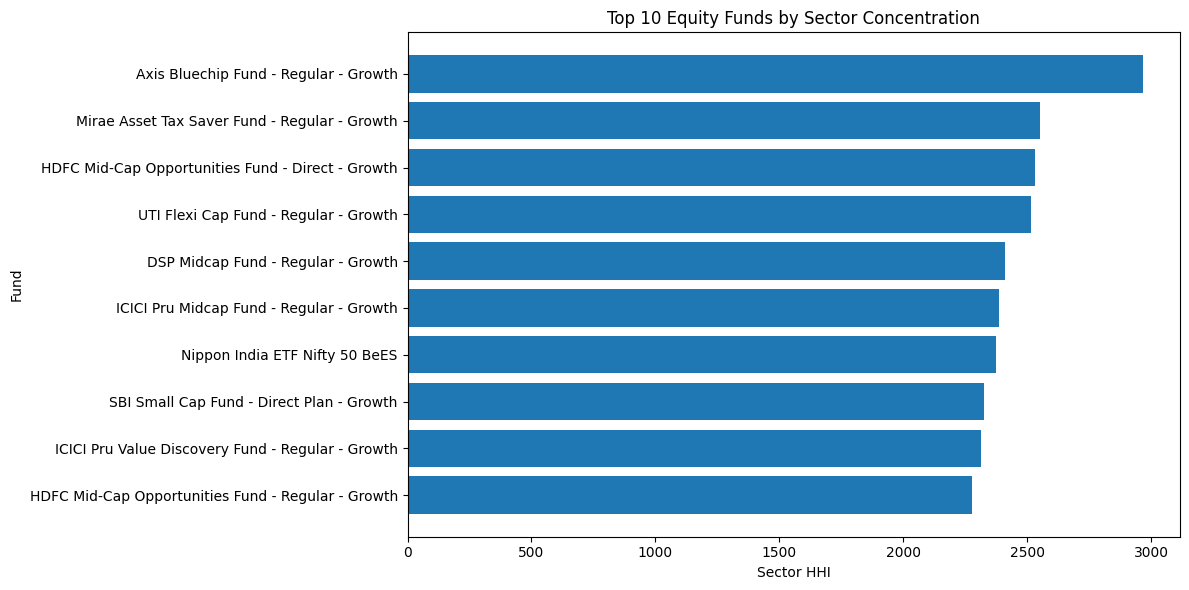

Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\sector_hhi_chart.png


In [25]:
import matplotlib.pyplot as plt

top10_hhi = sector_hhi.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_hhi["scheme_name"],
    top10_hhi["sector_hhi"]
)

plt.xlabel("Sector HHI")
plt.ylabel("Fund")
plt.title("Top 10 Equity Funds by Sector Concentration")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "sector_hhi_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    REPORTS_DIR / "sector_hhi_chart.png"
)

In [26]:
# ==========================================
# Advanced Analytics - Key Result Summary
# ==========================================

# 1. Fund with most negative VaR
worst_var = (
    var_report
    .sort_values("VaR_95_pct")
    .iloc[0]
)

# 2. Fund with most negative CVaR
worst_cvar = (
    var_report
    .sort_values("CVaR_95_pct")
    .iloc[0]
)

# 3. Cohort with highest average SIP
best_cohort = (
    cohort_analysis
    .sort_values("avg_sip_amount", ascending=False)
    .iloc[0]
)

# 4. At-risk SIP investors
at_risk_count = (
    sip_continuity["status"]
    .eq("At-Risk")
    .sum()
)

total_continuity_investors = len(sip_continuity)

# 5. Highest sector concentration
highest_hhi = sector_hhi.iloc[0]

print("1. Highest downside VaR:")
print(worst_var["scheme_name"], round(worst_var["VaR_95_pct"], 2), "%")

print("\n2. Highest downside CVaR:")
print(worst_cvar["scheme_name"], round(worst_cvar["CVaR_95_pct"], 2), "%")

print("\n3. Cohort with highest average SIP:")
print(int(best_cohort["cohort_year"]),
      "₹", round(best_cohort["avg_sip_amount"], 2))

print("\n4. At-risk SIP investors:")
print(at_risk_count, "out of", total_continuity_investors)

print("\n5. Highest sector concentration:")
print(highest_hhi["scheme_name"],
      round(highest_hhi["sector_hhi"], 2))

1. Highest downside VaR:
SBI Small Cap Fund - Direct Plan - Growth -2.69 %

2. Highest downside CVaR:
ABSL Small Cap Fund - Regular - Growth -3.25 %

3. Cohort with highest average SIP:
2025 ₹ 13505.21

4. At-risk SIP investors:
1361 out of 1362

5. Highest sector concentration:
Axis Bluechip Fund - Regular - Growth 2967.69


In [28]:
# ==========================================
# Day 6 Deliverables Check
# ==========================================

required_files = [
    PROJECT_ROOT / "notebooks" / "Advanced_Analytics.ipynb",
    REPORTS_DIR / "var_cvar_report.csv",
    REPORTS_DIR / "rolling_sharpe_chart.png",
    REPORTS_DIR / "cohort_analysis.csv",
    REPORTS_DIR / "sip_continuity.csv",
    REPORTS_DIR / "sector_hhi.csv",
    REPORTS_DIR / "sector_hhi_chart.png",
    PROJECT_ROOT / "scripts" / "recommender.py"
]

for file in required_files:
    status = "✅" if file.exists() else "❌"
    print(status, file.relative_to(PROJECT_ROOT))

✅ notebooks\Advanced_Analytics.ipynb
✅ reports\var_cvar_report.csv
❌ reports\rolling_sharpe_chart.png
✅ reports\cohort_analysis.csv
✅ reports\sip_continuity.csv
✅ reports\sector_hhi.csv
✅ reports\sector_hhi_chart.png
❌ scripts\recommender.py


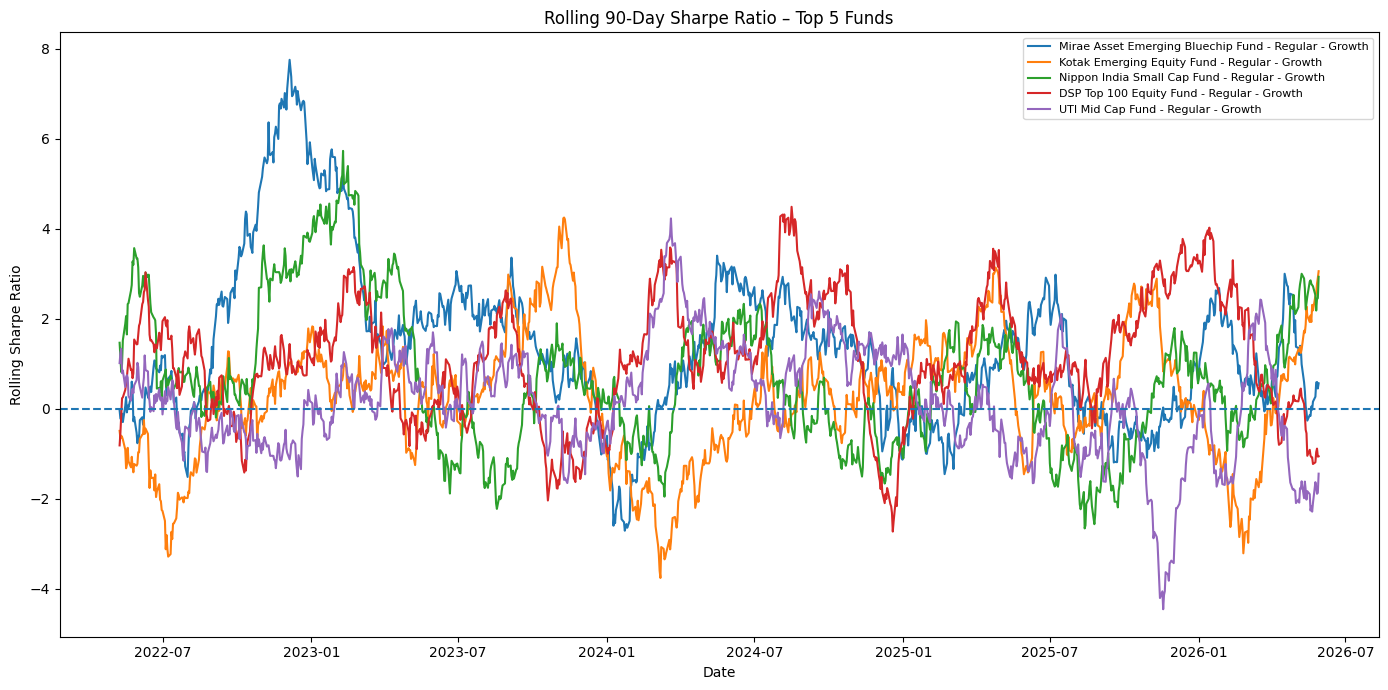

✅ Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\rolling_sharpe_chart.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 7))

for code in top5_codes:
    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == code
    ]

    fund_name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ]

    label = fund_name.iloc[0] if not fund_name.empty else code

    plt.plot(
        temp["date"],
        temp["rolling_sharpe_90d"],
        label=label
    )

plt.axhline(0, linestyle="--")
plt.title("Rolling 90-Day Sharpe Ratio – Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.tight_layout()

output_file = REPORTS_DIR / "rolling_sharpe_chart.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", output_file)